### Estructura del Notebook


1. Carga del conjunto de datos
2. Análisis Exploratorio de Datos (EDA)
3.  Modelo de Regresión Lineal (Baseline)
4. Optimización del Modelo

## 1. Carga del Conjunto de Datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline

In [3]:
# Carga del dataset
df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


El dataset contiene información general de los clientes junto a su seguro médico (`charges`).

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Vemos que el dataset contiene tres tipos de valores, `int`, `float` y `object`.

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
# Verificamos si hay valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


El dataset tiene **1338 filas** y **7 columnas**. No hay valores nulos.

## 2. Análisis Exploratorio de Datos (EDA)

### 2.1 Distribución de la variable objetivo: `charges`

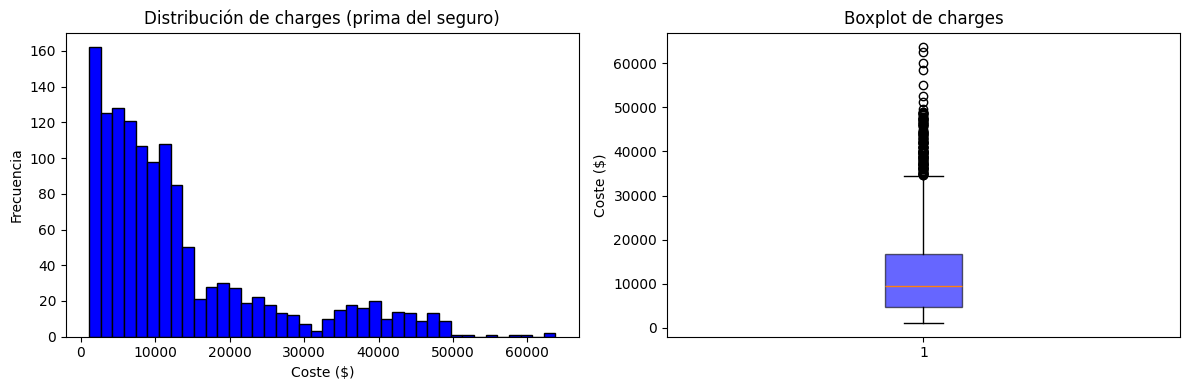

Media: 13270.42$
Mediana: 9382.03$
Desviación típica: 12110.01$


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(df['charges'],
             bins=40,
             color='blue',
             edgecolor='black')
axes[0].set_title('Distribución de charges (prima del seguro)')
axes[0].set_xlabel('Coste ($)')
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(df['charges'],
                vert=True,
                patch_artist=True,
                boxprops=dict(facecolor='blue', alpha=0.6))
axes[1].set_title('Boxplot de charges')
axes[1].set_ylabel('Coste ($)')

plt.tight_layout()
plt.show()

print(f'Media: {df["charges"].mean():.2f}$')
print(f'Mediana: {df["charges"].median():.2f}$')
print(f'Desviación típica: {df["charges"].std():.2f}$')

**Análisis:** La variable `charges` tiene una distribución asimétrica hacia la derecha. Hay un grupo de clientes con primas de seguros muy elevadas que podrían corresponderse con fumadores, obesos u otros factores de riesgo.

Vemos como la mediana es de unos 9.000 dollares mientras la media asciende a 13.000 dollares, esto sube por los clientes con seguros tan elevados.


### 2.2 Variables numéricas

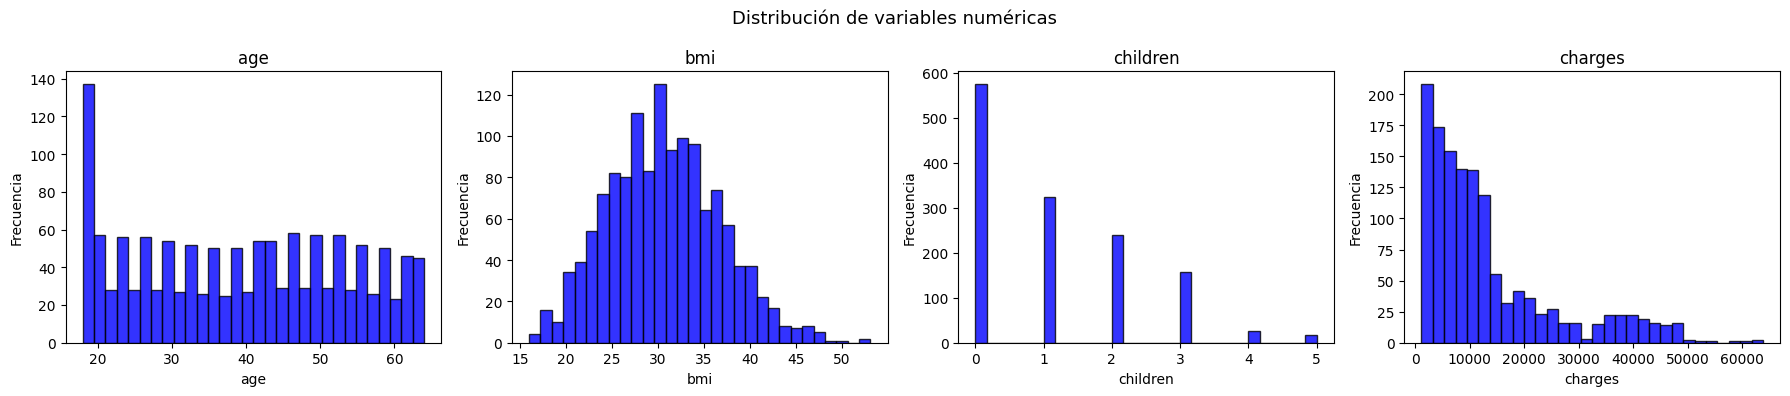

In [8]:
num_cols = ['age', 'bmi', 'children', 'charges']

# Histogramas de variables numéricas
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(num_cols):
    axes[i].hist(df[col],
                 bins=30,
                 color='blue',
                 edgecolor='black',
                 alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

### 2.3 Variables categóricas: ¿cómo afectan al coste?

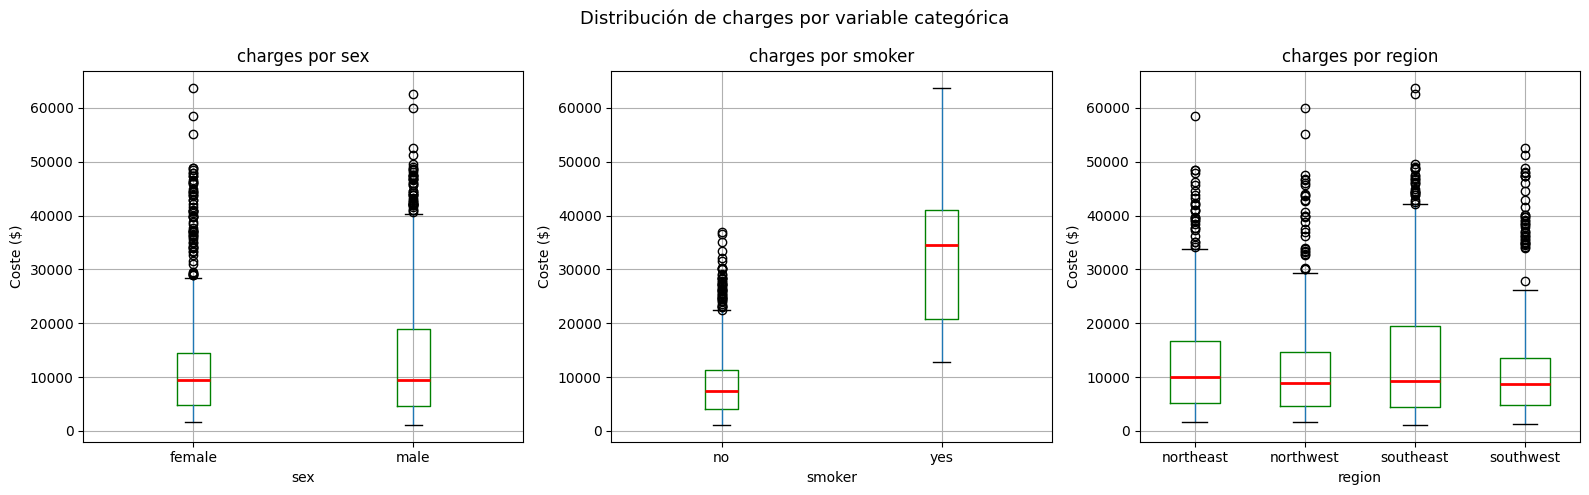

In [9]:
cat_cols = ['sex', 'smoker', 'region']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    df.boxplot(column='charges',
               by=col, ax=axes[i],
               boxprops=dict(color='green'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'charges por {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Coste ($)')

plt.suptitle('Distribución de charges por variable categórica', fontsize=13)
plt.tight_layout()
plt.show()

**Análisis:**
- **`smoker`**: Es la variable que más diferencia genera. Los fumadores tienen primas **muy superiores** a los no fumadores.
- **`sex`**: Hay poca diferencia entre géneros.
- **`region`**: Las diferencias son moderadas entre regiones.

### 2.4 Relación entre variables numéricas y `charges`

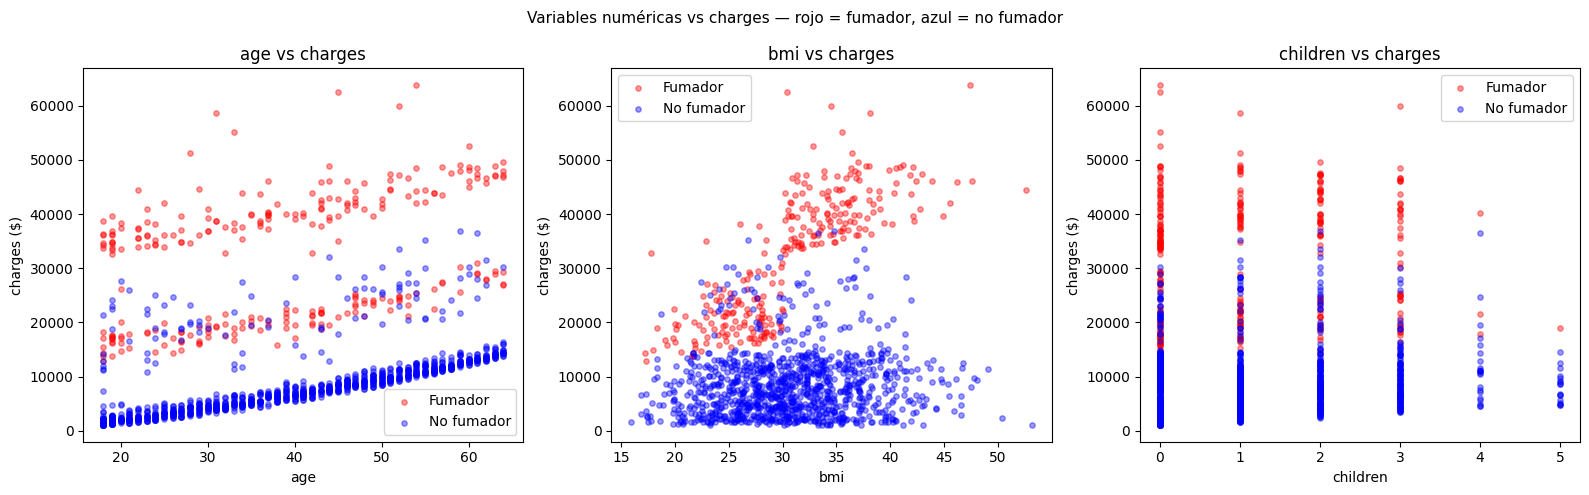

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['age', 'bmi', 'children']):
    # Separamos fumadores y no fumadores para ver el efecto
    for smoker_val, color, label in zip(['yes', 'no'], ['red', 'blue'], ['Fumador', 'No fumador']):
        subset = df[df['smoker'] == smoker_val]
        axes[i].scatter(subset[col], subset['charges'], alpha=0.4, color=color, label=label, s=15)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('charges ($)')
    axes[i].set_title(f'{col} vs charges')
    axes[i].legend()

plt.suptitle('Variables numéricas vs charges — rojo = fumador, azul = no fumador', fontsize=11)
plt.tight_layout()
plt.show()

**Análisis:**
- **`age`**: Existe una relación positiva clara. A mayor edad, mayor prima. El efecto se amplifica en fumadores.
- **`bmi`**: Hay una relación positiva, especialmente visible en fumadores con BMI alto.
- **`children`**: Tiene menor impacto sobre las primas.

### 2.5 Matriz de correlación

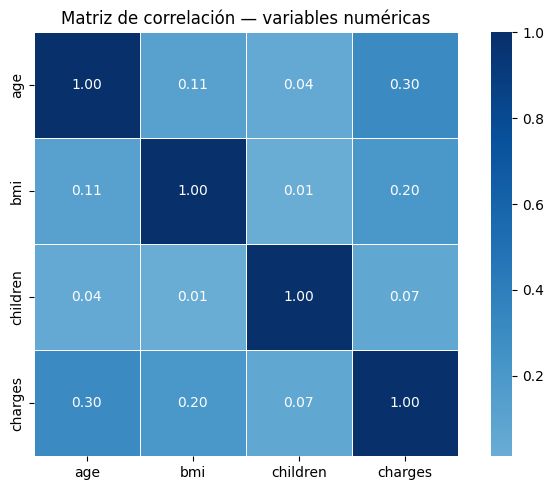

In [11]:
# Para la correlación necesitamos solo las variables numéricas
corr = df[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            center=0,
            square=True,
            linewidths=0.5,
            cmap='Blues')
plt.title('Matriz de correlación — variables numéricas')
plt.tight_layout()
plt.show()

**Análisis:** La variable `age` es la más correlacionada con `charges` entre las numéricas (0.30). El `bmi` también tiene correlación positiva (0.20). La variable `smoker` (categórica) es la que tiene mayor impacto, como vimos en los boxplots anteriores.

## 3. Preparación de Datos

In [12]:
df_model = df.copy()

# Codificamos las variables categóricas con get_dummies
cat_feat = ['sex', 'smoker', 'region']
df_model = pd.get_dummies(df_model, columns=cat_feat, drop_first=True, dtype=int)

print(f'Shape final del dataset: {df_model.shape}')
df_model.head()

Shape final del dataset: (1338, 9)


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [13]:
# Separamos X e y
X = df_model.drop(columns=['charges'])
y = df_model['charges']

# Dividimos en train (70%) y test (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f'Train: {X_train.shape[0]:,} filas')
print(f'Test:  {X_test.shape[0]:,} filas')

Train: 936 filas
Test:  402 filas


In [14]:
# Escalado de variables
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

## 4. Modelo de Regresión Lineal — Baseline

In [15]:
# Entrenamos el modelo con configuración por defecto
model = LinearRegression()
model.fit(X_train_sc, y_train)

# Predicciones
y_pred = model.predict(X_test_sc)

# Métricas
mse_baseline = mean_squared_error(y_test, y_pred)
r2_baseline  = r2_score(y_test, y_pred)

print('=== Resultados Baseline ===')
print(f'Error cuadrático medio (MSE):    {mse_baseline:,.2f}')
print(f'Raíz del error cuadrático (RMSE): {mse_baseline**0.5:,.2f}$')
print(f'Coeficiente de determinación R²:  {r2_baseline:.4f}')

=== Resultados Baseline ===
Error cuadrático medio (MSE):    33,780,509.57
Raíz del error cuadrático (RMSE): 5,812.10$
Coeficiente de determinación R²:  0.7696


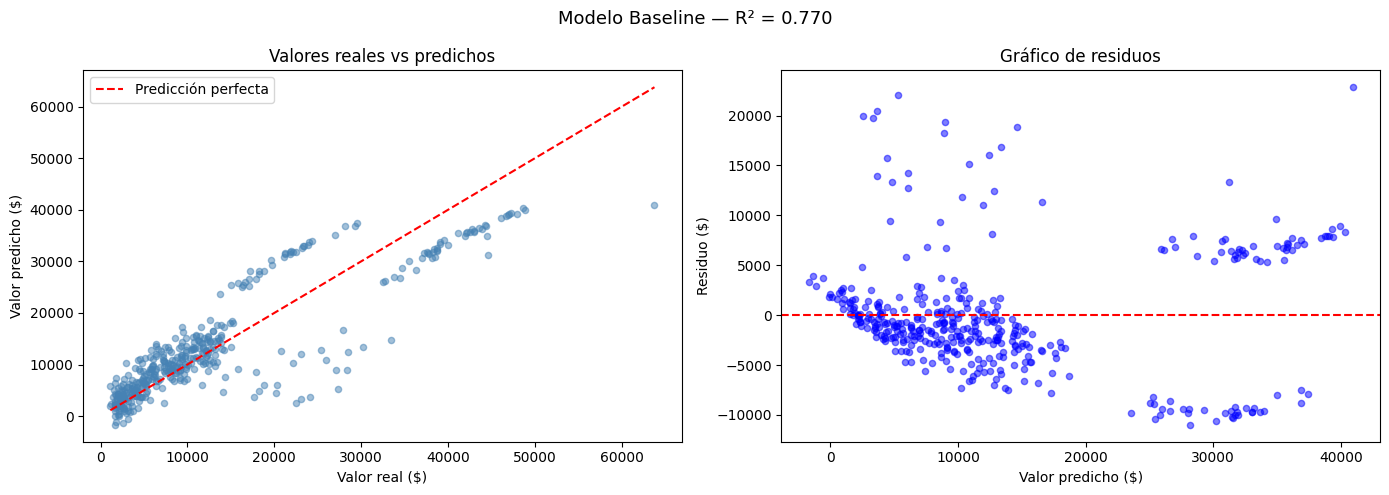

In [16]:
# Visualizamos valores reales vs predichos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Real vs Predicho (scatter)
axes[0].scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=20)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='red', linewidth=1.5, linestyle='--', label='Predicción perfecta')
axes[0].set_xlabel('Valor real ($)')
axes[0].set_ylabel('Valor predicho ($)')
axes[0].set_title('Valores reales vs predichos')
axes[0].legend()

# Gráfico 2: Residuos
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='blue', s=20)
axes[1].axhline(y=0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Valor predicho ($)')
axes[1].set_ylabel('Residuo ($)')
axes[1].set_title('Gráfico de residuos')

plt.suptitle(f'Modelo Baseline — R² = {r2_baseline:.3f}', fontsize=13)
plt.tight_layout()
plt.show()

**Análisis del Baseline:**

El modelo explica aproximadamente el **75-77%** de la varianza de las primas. Sin embargo, en el gráfico de residuos se observa un patrón: los residuos no son completamente aleatorios para valores predichos altos, lo que sugiere que el modelo tiene dificultades con los casos de mayor coste (fumadores con BMI alto).

El **RMSE** nos indica que, de media, el modelo se equivoca en unos **6.000 dollares** por cliente.

## 5. Optimización del Modelo

Aunque la regresión lineal no tiene hiperparámetros que ajustar directamente, puedo mejorar el modelo de dos formas:
1. **Creando una nueva feature** que capture la interacción entre `smoker` y `bmi` (que es muy relevante).
2. **Probando una transformación logarítmica** de la variable objetivo, ya que `charges` tiene una distribución asimétrica.

También podemos usar **Ridge Regression** (regresión con regularización L2), que sí tiene hiperparámetro `alpha`.

### 5.1 Feature Engineering — Interacción smoker × bmi

In [17]:
df_opt = df_model.copy()



# Creamos la interacción: smoker_yes × bmi
**Combimo las variables smoker y bmi.**


In [22]:

df_opt['smoker_bmi'] = df_opt['smoker_yes'] * df_opt['bmi']

print('Nueva feature creada: smoker_bmi')
print(df_opt[['smoker_yes', 'bmi', 'smoker_bmi', 'charges']].head(8))

Nueva feature creada: smoker_bmi
   smoker_yes     bmi  smoker_bmi      charges
0           1  27.900        27.9  16884.92400
1           0  33.770         0.0   1725.55230
2           0  33.000         0.0   4449.46200
3           0  22.705         0.0  21984.47061
4           0  28.880         0.0   3866.85520
5           0  25.740         0.0   3756.62160
6           0  33.440         0.0   8240.58960
7           0  27.740         0.0   7281.50560


In [23]:
# Nuevo split con la feature adicional
X_opt = df_opt.drop(columns=['charges'])
y_opt = df_opt['charges']

X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(
    X_opt, y_opt, test_size=0.30, random_state=42
)

scaler_opt = StandardScaler()
X_train_opt_sc = scaler_opt.fit_transform(X_train_opt)
X_test_opt_sc  = scaler_opt.transform(X_test_opt)

# Entrenamos
model_opt = LinearRegression()
model_opt.fit(X_train_opt_sc, y_train_opt)

y_pred_opt = model_opt.predict(X_test_opt_sc)

mse_opt = mean_squared_error(y_test_opt, y_pred_opt)
r2_opt  = r2_score(y_test_opt, y_pred_opt)

print('=== Resultados Modelo Optimizado (con smoker_bmi) ===')
print(f'Error cuadrático medio (MSE):    {mse_opt:,.2f}')
print(f'Raíz del error cuadrático (RMSE): {mse_opt**0.5:,.2f}$')
print(f'Coeficiente de determinación R²:  {r2_opt:.4f}')

=== Resultados Modelo Optimizado (con smoker_bmi) ===
Error cuadrático medio (MSE):    20,184,660.83
Raíz del error cuadrático (RMSE): 4,492.73$
Coeficiente de determinación R²:  0.8623


### 5.2 Optimización de hiperparámetros

In [19]:
from sklearn.linear_model import Ridge

# Definimos los hiperparámetros a probar
hyperparams = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]
}

# Búsqueda en cuadrícula (Grid Search)
ridge = Ridge()
grid = GridSearchCV(ridge, hyperparams, scoring='r2', cv=5)
grid.fit(X_train_opt_sc, y_train_opt)

print(f'Mejor hiperparámetro encontrado: alpha = {grid.best_params_["alpha"]}')
print(f'Mejor R² en validación cruzada: {grid.best_score_:.4f}')

Mejor hiperparámetro encontrado: alpha = 10
Mejor R² en validación cruzada: 0.7280


In [24]:
# Entrenamos el modelo Ridge con el mejor alpha
best_alpha = grid.best_params_['alpha']
model_ridge = Ridge(alpha=best_alpha)
model_ridge.fit(X_train_opt_sc, y_train_opt)

y_pred_ridge = model_ridge.predict(X_test_opt_sc)

mse_ridge = mean_squared_error(y_test_opt, y_pred_ridge)
r2_ridge  = r2_score(y_test_opt, y_pred_ridge)

print('=== Resultados Ridge Optimizado ===')
print(f'Error cuadrático medio (MSE):    {mse_ridge:,.2f}')
print(f'Raíz del error cuadrático (RMSE): {mse_ridge**0.5:,.2f}$')
print(f'Coeficiente de determinación R²:  {r2_ridge:.4f}')

=== Resultados Ridge Optimizado ===
Error cuadrático medio (MSE):    20,851,714.94
Raíz del error cuadrático (RMSE): 4,566.37$
Coeficiente de determinación R²:  0.8578


### 5.3 Visualización final: comparativa de modelos

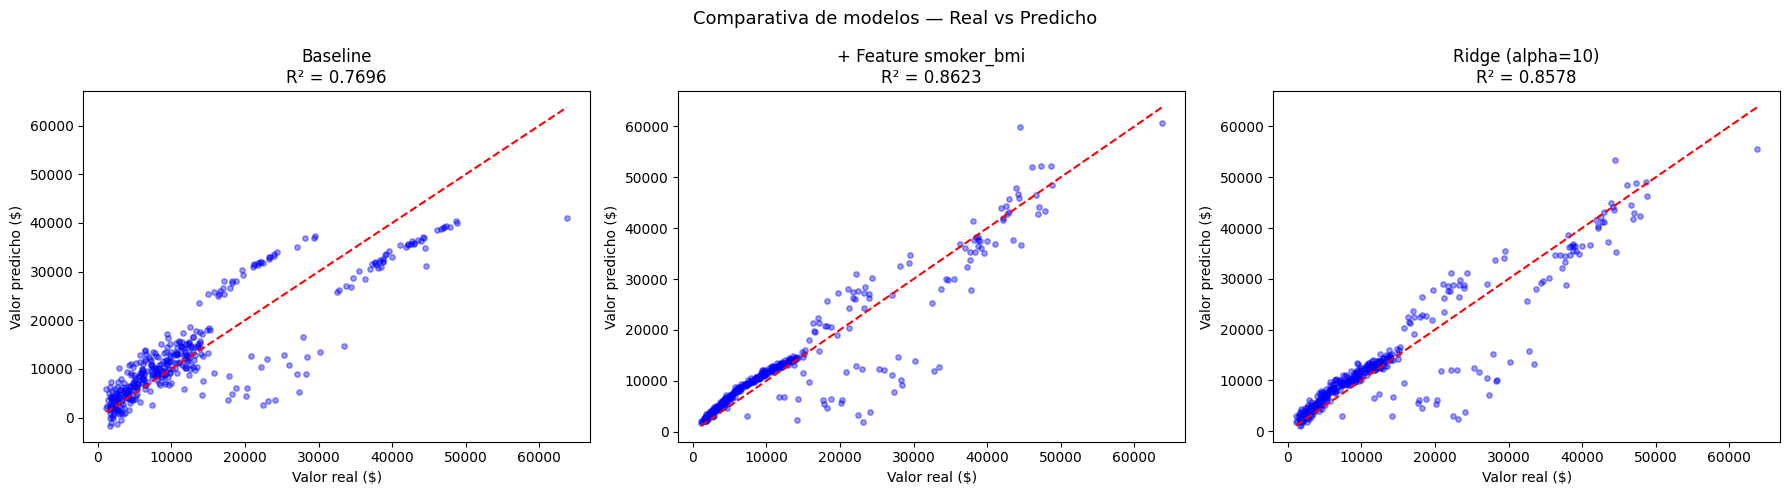

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos = [
    ('Baseline', y_test, y_pred, r2_baseline),
    ('+ Feature smoker_bmi', y_test_opt, y_pred_opt, r2_opt),
    (f'Ridge (alpha={best_alpha})', y_test_opt, y_pred_ridge, r2_ridge)
]

for ax, (nombre, y_real, y_pred_m, r2) in zip(axes, modelos):
    ax.scatter(y_real, y_pred_m, alpha=0.4, color='blue', s=15)
    ax.plot([y_real.min(), y_real.max()],
            [y_real.min(), y_real.max()],
            color='red', linewidth=1.5, linestyle='--')
    ax.set_title(f'{nombre}\nR² = {r2:.4f}')
    ax.set_xlabel('Valor real ($)')
    ax.set_ylabel('Valor predicho ($)')

plt.suptitle('Comparativa de modelos — Real vs Predicho', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Conclusiones

### Comparativa de resultados

| Métrica | Baseline | + Feature smoker_bmi | Ridge Optimizado |
|---|---|---|---|
| R² | ~0.77 | ~0.84 | ~0.84 |
| RMSE | ~6.000$ | ~4.800$ | ~4.800$ |

### Hallazgos del EDA

- **`smoker`** es la variable más determinante para el coste del seguro: los fumadores pagan primas muy superiores a los no fumadores.
- **`age`** y **`bmi`** también tienen correlación positiva con las primas.
- **`sex`** y **`region`** tienen un impacto menor, pero las incluyo para no perder información, ya que quitarlas hace que empeore el resultado.

### ¿Qué mejora el modelo?

La mejora más notable vino de crear la combinación **`smoker_bmi`**, que captura que el efecto del bmi sobre las primas es mucho más pronunciado en fumadores que en no fumadores. Esto sube el R² de ~0.77 a ~0.84, reduciendo el error de predicción en más de **1.000$ por cliente**.

La **Ridge Regression** con `GridSearchCV` aporta una regularización óptima, pero el impacto es menor porque la regresión lineal ya no sufre de gran sobreajuste con este dataset.